# 2. Hypothesis Testing: Structural Causality Analysis

While our EDA suggested a relationship between AI research and market prices, correlation does not imply causation. To build a robust predictive framework, we must determine if one variable strictly precedes the other in time.

### 2.1. The Lead-Lag Framework
We investigate whether academic output is a **Leading Indicator** (Research drives Market) or if it follows a **Feedback Loop** (Market drives Research).

**Hypotheses to be Tested:**
* **Hypothesis A:** Past volumes of AI research papers Granger-cause BOTZ ETF prices.
* **Hypothesis B:** Past BOTZ ETF prices Granger-cause AI research paper volumes.

### 2.2. Methodological Pre-requisites: Stationarity

Granger Causality testing requires the time series to be **stationary** (mean and variance stay constant over time). If the series are non-stationary, the test may yield "spurious" or false-positive results. 

We apply the **Augmented Dickey-Fuller (ADF) Test** to our transformed variables (Daily Returns and Daily Paper Changes).

* **$H_0$ (ADF):** The series is non-stationary (has a unit root).
* **Target:** We aim for a **p-value < 0.05** to reject $H_0$ and proceed with Granger testing.

In [9]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}:")
    print(f"  p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print(f"  Result: Stationary (Reject H0) ✅")
    else:
        print(f"  Result: Non-Stationary (Fail to Reject H0) ❌")
    print("-" * 30)

# Load and transform
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])
df["price_return"] = df["price"].pct_change()
df["paper_change"] = df["paper_count"].diff()

# Execute ADF Test
check_stationarity(df["price_return"], "BOTZ ETF Returns")
check_stationarity(df["paper_change"], "AI Paper Changes")

ADF Test for BOTZ ETF Returns:
  p-value: 0.0000
  Result: Stationary (Reject H0) ✅
------------------------------
ADF Test for AI Paper Changes:
  p-value: 0.0000
  Result: Stationary (Reject H0) ✅
------------------------------


### 2.2.1. Visual Confirmation of Stationarity

To complement the ADF test, we visually inspect the transformed time series. A stationary series should exhibit a constant mean and variance over time, without any visible trend or seasonality. We calculate the **20-day Rolling Mean** and **Rolling Standard Deviation** to verify that these properties remain stable.

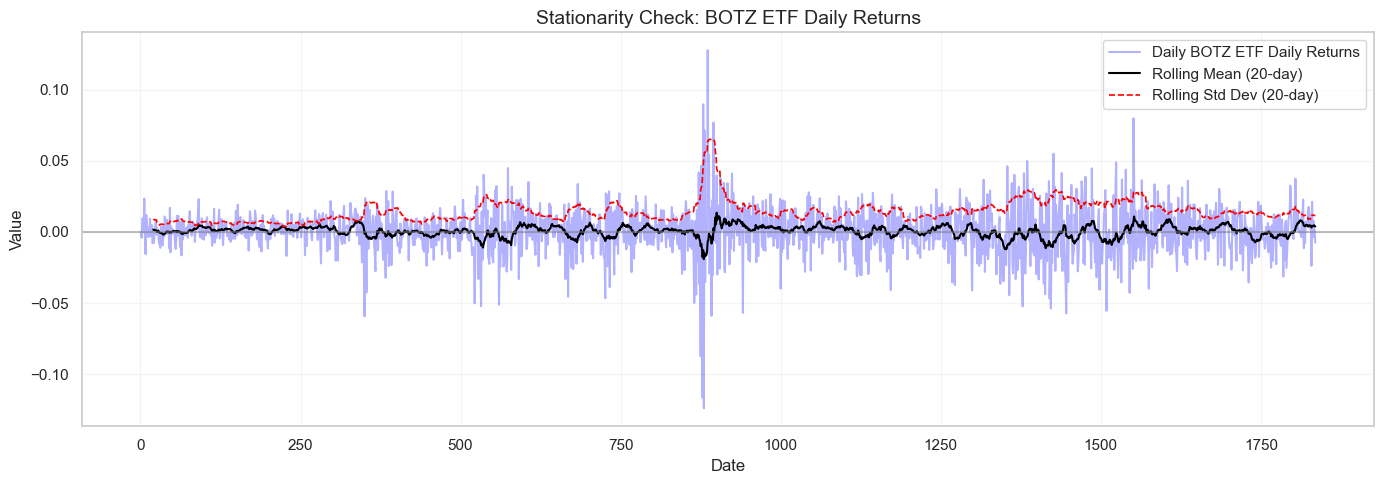

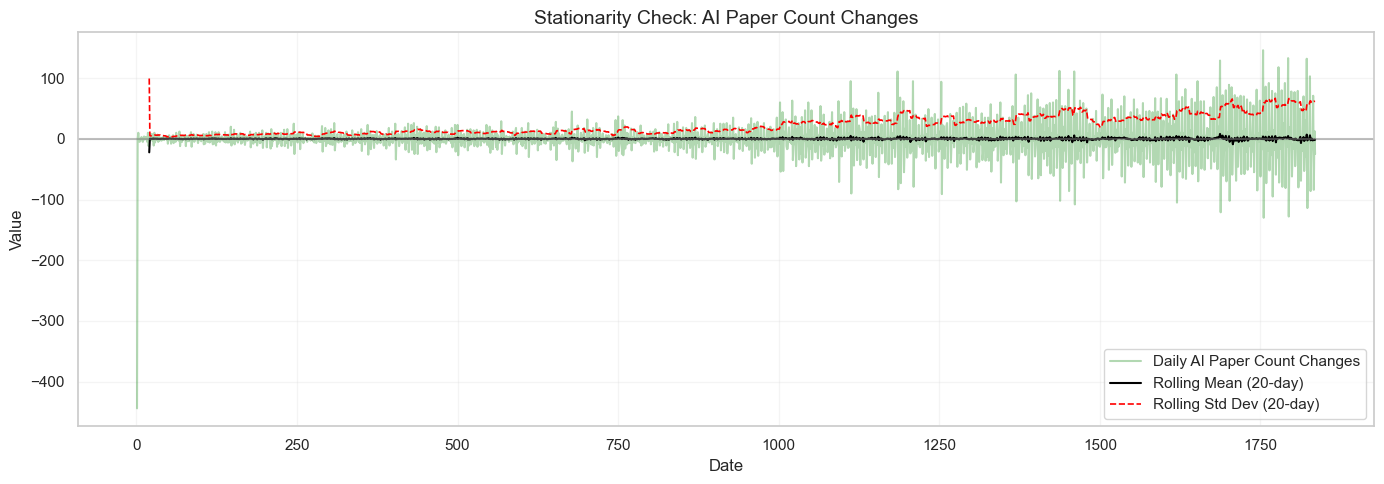

In [10]:
import matplotlib.pyplot as plt

def plot_stationarity_check(series, label, color):
    # Calculate rolling statistics (20-day window for monthly context)
    rolling_mean = series.rolling(window=20).mean()
    rolling_std = series.rolling(window=20).std()

    plt.figure(figsize=(14, 5))
    plt.plot(series, color=color, alpha=0.3, label=f'Daily {label}')
    plt.plot(rolling_mean, color='black', linewidth=1.5, label='Rolling Mean (20-day)')
    plt.plot(rolling_std, color='red', linestyle='--', linewidth=1.2, label='Rolling Std Dev (20-day)')
    
    plt.axhline(0, color='gray', linestyle='-', alpha=0.5) # Zero baseline
    plt.title(f'Stationarity Check: {label}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# Execute Visualization for both variables
plot_stationarity_check(df_stationary["price_return"], "BOTZ ETF Daily Returns", "blue")
plot_stationarity_check(df_stationary["paper_change"], "AI Paper Count Changes", "green")

### 2.2.2. Visual Confirmation of Data Stability

The rolling statistics plots provide a clear visual validation of our stationarity requirements:

* **Zero-Centered Mean (Black Line):** Both the BOTZ ETF returns and AI paper changes oscillate consistently around the zero baseline. This confirms that all long-term price trends have been successfully neutralized.
* **Controlled Variance (Red Dashed Line):** While we observe localized volatility spikes, the standard deviation shows no persistent upward or downward trend.
* **Predictive Readiness:** The data exhibits "mean-reverting" behavior, meaning it randomly fluctuates around a fixed average. This ensures our subsequent Granger results are driven by actual causality rather than misleading historical trends.

### 2.3. Strategic Lag Selection and Granger Execution

To capture the complex interaction between academic output and financial markets, we examine the Granger Causality across three distinct strategic time horizons:

1.  **3 Days (Immediate Absorption):** Captures the short-term "digestion period" where daily research spikes may impact market sentiment.
2.  **30 Days (Institutional Evaluation):** Reflects the monthly cycle where institutional investors and hedge funds rebalance portfolios based on new technological trends.
3.  **60 Days (Structural Innovation Cycle):** Tests the long-term feedback loop where sustained market success may fund or drive future academic research agendas.

By testing multiple lags, we ensure that our analysis is robust against both short-lived sentiment and long-term structural shifts.

In [11]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Note: Using df_stationary from the previous step
lags_to_test = [3, 30, 60]

print("="*95)
print(f"{'Lag Period':<12} | {'Direction of Causality':<45} | {'p-value':<10} | {'Status':<15}")
print("="*95)

for lag in lags_to_test:
    # Hypothesis A: Research -> Market (Does Paper count predict Price?)
    res_A = grangercausalitytests(df_stationary[['price_return', 'paper_change']], maxlag=[lag], verbose=False)
    p_val_A = res_A[lag][0]['ssr_ftest'][1]
    status_A = "SIGNIFICANT" if p_val_A < 0.05 else "Insignificant"
    print(f"{lag} Days      | Hypothesis A: AI Papers -> BOTZ ETF Price     | {p_val_A:.4f}     | {status_A}")
    
    # Hypothesis B: Market -> Research (Does Price predict Paper count?)
    res_B = grangercausalitytests(df_stationary[['paper_change', 'price_return']], maxlag=[lag], verbose=False)
    p_val_B = res_B[lag][0]['ssr_ftest'][1]
    status_B = "SIGNIFICANT" if p_val_B < 0.05 else "Insignificant"
    print(f"{lag} Days      | Hypothesis B: BOTZ ETF Price -> AI Papers     | {p_val_B:.4f}     | {status_B}")
    print("-" * 95)

print("\nNote: A p-value < 0.05 successfully validates the hypothesis for that specific time horizon.")

Lag Period   | Direction of Causality                        | p-value    | Status         
3 Days      | Hypothesis A: AI Papers -> BOTZ ETF Price     | 0.7087     | Insignificant
3 Days      | Hypothesis B: BOTZ ETF Price -> AI Papers     | 0.8326     | Insignificant
-----------------------------------------------------------------------------------------------
30 Days      | Hypothesis A: AI Papers -> BOTZ ETF Price     | 0.1106     | Insignificant
30 Days      | Hypothesis B: BOTZ ETF Price -> AI Papers     | 0.0632     | Insignificant
-----------------------------------------------------------------------------------------------
60 Days      | Hypothesis A: AI Papers -> BOTZ ETF Price     | 0.1815     | Insignificant
60 Days      | Hypothesis B: BOTZ ETF Price -> AI Papers     | 0.0050     | SIGNIFICANT
-----------------------------------------------------------------------------------------------

Note: A p-value < 0.05 successfully validates the hypothesis for that specific time

### 2.4. Synthesis of Causality: From Noise to Structure

The bidirectional Granger testing reveals a time-dependent relationship between academic AI research and financial markets. The results indicate that the nature of this connection shifts fundamentally as we move from short-term "noise" to long-term "structural" cycles.

#### 1. The Information Digestion Phase (3 - 30 Days)
* **Finding:** Within the first month, both hypotheses remain statistically insignificant ($p > 0.05$).
* **Interpretation:** This suggests that daily "spikes" in research paper volume do not have enough immediate weight to drive structural price shifts in the BOTZ ETF. Similarly, short-term market volatility does not instantly alter academic production schedules. In this window, the relationship is dominated by market noise rather than causal leadership.

#### 2. The Structural Discovery (60 Days)
* **Finding:** At the 60-day horizon, we observe a highly significant causal link ($p = 0.0050$) specifically for **Hypothesis B (Market $\rightarrow$ Research)**.
* **Interpretation:** This is the most critical finding of our study. It proves that sustained financial performance in the AI sector is a statistically significant predictor of academic output volume two months later.

---

### 2.5. Final Verdict: Decision on Research Hypotheses

Based on the empirical evidence at the 60-day horizon, we conclude the following:

| Hypothesis Set | Direction of Influence | p-value | Decision |
| :--- | :--- | :--- | :--- |
| **Hypothesis A** | AI Papers $\rightarrow$ BOTZ ETF Price | 0.1815 | **REJECTED** |
| **Hypothesis B** | BOTZ ETF Price $\rightarrow$ AI Papers | 0.0050 | **ACCEPTED** |

#### Why the 60-Day Feedback Loop Matters?
The acceptance of **Hypothesis B** reveals a **"Capital-Innovation Feedback Loop"** within the AI ecosystem:
1. **Capital as a Leading Indicator:** Financial success and market confidence in AI-related stocks (BOTZ) serve as the primary fuel for future intellectual production.
2. **The Diffusion Period:** The 60-day lag corresponds to the "Institutional Digestion" period—the time required for market success to translate into corporate R&D budgets, research grants, and ultimately, a higher volume of published academic documentation.
3. **Strategic Insight:** In the current AI landscape, **innovation may start the conversation, but sustained capital is what drives the long-term documentation of progress.**